# **Projeto LTV e Segmentação**

Objetivo: Agrupar clientes por comportamento de compra (Segmentação) e prever quanto eles vão gastar no futuro, o chamado LTV (*Lifetime Value*), utilizando uma base que possui dados reais de transações de um e-commerce no Reino Unido entre dez/2010 e dez/2011.  

Dataset: "Online Retail Dataset", UCI Machine Learning Repository.

### Inspeção e Preparação da Base:

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('online_retail.csv', delimiter=';')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  object 
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [7]:
df.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01/12/2010 08:26,"7,65",17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01/12/2010 08:26,"4,25",17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01/12/2010 08:28,"1,85",17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01/12/2010 08:28,"1,85",17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01/12/2010 08:34,"1,69",13047.0,United Kingdom


Verificação de dados nulos:

In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Remoção de dados nulos:  

- a coluna 'Description' possui 1454 linhas com dados ausentes, não substituíveis e pouco representativos dada sua proporção em relação ao total da base, o que justifica o descarte dessas instâncias;  

- a coluna 'CustomerID' tem um grande volume de dados ausentes e também não substituíveis, pois são dados únicos de cada comprador.  
 Não havendo opção viável para substituição, apesar da remoção significar a perda de quase 25% da base, opto pelo descarte, pois trata-se de uma variável fundamental para o escopo do projeto que é justamente captar o perfil dos clientes.  

In [9]:
# Eliminação de nulos na variável de descrição de produto:

df = df.dropna(subset='Description', axis=0)

In [10]:
# Eliminação de nulos na variável de ID de cliente:

df = df.dropna(subset='CustomerID', axis=0)

In [11]:
# Conferência:

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


Verificação de Duplicadas:

In [12]:
df.duplicated().sum()

np.int64(5225)

In [13]:
# Remoção:

df = df.drop_duplicates(ignore_index=True)

In [14]:
df.duplicated().sum()

np.int64(0)

Conversão de tipos:

In [15]:
# CustomerID:

df['CustomerID'] = df['CustomerID'].astype(int)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401604 entries, 0 to 401603
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   InvoiceNo    401604 non-null  object
 1   StockCode    401604 non-null  object
 2   Description  401604 non-null  object
 3   Quantity     401604 non-null  int64 
 4   InvoiceDate  401604 non-null  object
 5   UnitPrice    401604 non-null  object
 6   CustomerID   401604 non-null  int64 
 7   Country      401604 non-null  object
dtypes: int64(2), object(6)
memory usage: 24.5+ MB


In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,"2,55",17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,"3,39",17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,"2,75",17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,"3,39",17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,"3,39",17850,United Kingdom


In [18]:
# UnitPrice:

df['UnitPrice'] = df['UnitPrice'].str.replace(',', '.').astype(float)

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850,United Kingdom


In [20]:
# InvoiceDate:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


Conferência das variáveis contínuas "Quantity" e "UnitPrice":

In [21]:
# Quantity

len(df[df['Quantity'] <= 0])

8872

In [22]:
df[df['Quantity'] < 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548,United Kingdom
915,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897,United Kingdom


In [23]:
# UnitPrice

len(df[df['UnitPrice'] < 0])

0

Pela conferência acima vemos que a coluna de quantidade apresenta 8872 linhas com valores negativos.   

Esses registros coincidem com o número de fatura correspondente de cada transação na coluna "InvoiceNo" que iniciam com a letra de C de "cancelled". Ou seja, trata-se de vendas canceladas.  

Para o objetivo deste projeto, essas transações não são importantes, pois o foco é na análise do perfil de compra de cada cliente, e não nas vendas da loja em si.  

Assim, procedo com a remoção dessas linhas:

In [24]:
df = df[df['Quantity'] > 0].reset_index(drop=True)

In [25]:
len(df[df['Quantity'] < 0])

0

Verificação de dados únicos:

In [26]:
df.apply(lambda x: x.unique())

,0
InvoiceNo,"[536365, 536366, 536367, 536368, 536369, 53637..."
StockCode,"[85123A, 71053, 84406B, 84029G, 84029E, 22752,..."
Description,"[WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET..."
Quantity,"[6, 8, 2, 32, 3, 4, 24, 12, 48, 18, 20, 36, 80..."
InvoiceDate,"[2010-12-01 08:26:00, 2010-12-01 08:28:00, 201..."
UnitPrice,"[2.55, 3.39, 2.75, 7.65, 4.25, 1.85, 1.69, 2.1..."
CustomerID,"[17850, 13047, 12583, 13748, 15100, 15291, 146..."
Country,"[United Kingdom, France, Australia, Netherland..."


In [27]:
df.nunique()

,0
InvoiceNo,18536
StockCode,3665
Description,3877
Quantity,302
InvoiceDate,17286
UnitPrice,441
CustomerID,4339
Country,37


Pela contagem de dados únicos em cada variável temos:
- 18.536 transações;
- 3.877 produtos vendidos - e ao mesmo tempo apenas 3.665 códigos de produto, resultando em uma divergência de 212 descrições compartilhando códigos de estoque;  
- 4.339 clientes diferentes de 37 países.



A seguir, verificação da discrepância entre as descrições únicas de produto e códigos de estoque:

In [28]:
# Agrupamento das variáveis para conferência de produtos com mais de uma descrição:
produto_por_codigo = df.groupby('StockCode')['Description'].unique().reset_index()
produto_por_codigo['Qtd_Descricoes'] = produto_por_codigo['Description'].apply(len)
discrepancias = produto_por_codigo[produto_por_codigo['Qtd_Descricoes'] > 1].sort_values(by='Qtd_Descricoes', ascending=False)
discrepancias.head(20)

,StockCode,Description,Qtd_Descricoes
2066,23236,"[DOILEY STORAGE TIN, DOILEY BISCUIT TIN, STORA...",4
2026,23196,"[RETRO LEAVES MAGNETIC NOTEPAD, RETO LEAVES MA...",4
1625,22776,"[SWEETHEART CAKESTAND 3 TIER, CAKESTAND, 3 TIE...",3
1779,22937,"[BAKING MOULD CHOCOLATE CUPCAKES, BAKING MOULD...",3
100,17107D,"[FLOWER FAIRY,5 SUMMER B'DRAW LINERS, FLOWER F...",3
2061,23231,"[WRAP DOILEY DESIGN, WRAP VINTAGE DOILEY , WR...",3
2070,23240,"[SET OF 4 KNICK KNACK TINS DOILEY , SET OF 4 K...",3
2341,23535,"[BICYCLE SAFTEY WALL ART, WALL ART BICYCLE SAF...",3
2074,23244,"[ROUND STORAGE TIN VINTAGE LEAF, STORAGE TIN V...",3
2222,23413,"[VINTAGE COFFEE GRINDER BOX, DECROTIVEVINTAGE ...",3


A análise revela que de fato alguns códigos de estoque possuem mais de uma descrição, alguns com até 4 descrições distintas, possivelmente devido a erros de digitação ou edições de cadastro na base de dados.  
Como o objeto deste projeto foca no comportamento financeiro do cliente, as descrições na forma em que se apresentam não são obstáculo para a modelagem pretendida.  
Assim, essas inconsistências não receberão tratamento pois não haverá influência no objetivo final.

Apenas para registro, listagem dos 20 produtos mais vendidos e suas quantidades:

In [29]:
# 20 produtos mais vendidos

df['Description'].value_counts().sort_values(ascending=False).head(20)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2016
REGENCY CAKESTAND 3 TIER,1714
JUMBO BAG RED RETROSPOT,1615
ASSORTED COLOUR BIRD ORNAMENT,1395
PARTY BUNTING,1390
LUNCH BAG RED RETROSPOT,1303
SET OF 3 CAKE TINS PANTRY DESIGN,1152
POSTAGE,1099
LUNCH BAG BLACK SKULL.,1078


In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


### Criação de novas features:

A seguir, manipulação do DataFrame para extração das três métricas a ser utilizadas no modelo de segmentação:   


1.   Recência: A quantidade de dias desde a última compra
2.   Frequência: A quantidade de transações de cada cliente
3.   Valor monetário: O valor total acumulado em compras de cada cliente



Para gerar nova tabela com as novas métricas é necessário ajuste na variável de data e criação de nova feature com os dados do valor total da compra de cada item:

In [31]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
392727,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
392728,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
392729,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
392730,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


 - Transformação da feature da **data da compra** para remover os dados de horário:

In [32]:
df['InvoiceDay'] = df['InvoiceDate'].dt.normalize()
df['InvoiceDay']

,InvoiceDay
0,2010-12-01
1,2010-12-01
2,2010-12-01
3,2010-12-01
4,2010-12-01
...,...
392727,2011-12-09
392728,2011-12-09
392729,2011-12-09
392730,2011-12-09


- Criação de nova feature para conhecer o valor total por produto adquirido:

In [33]:
df['Total'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceDay,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34


#### 1. Recência

In [34]:
df_rfm = df.groupby('CustomerID')['InvoiceDay'].max().reset_index(name='LastPurchaseDate')
df_rfm

,CustomerID,LastPurchaseDate
0,12346,2011-01-18
1,12347,2011-12-07
2,12348,2011-09-25
3,12349,2011-11-21
4,12350,2011-02-02
...,...,...
4334,18280,2011-03-07
4335,18281,2011-06-12
4336,18282,2011-12-02
4337,18283,2011-12-06


In [35]:
df_rfm['Recency'] = (df['InvoiceDay'].max() - df_rfm['LastPurchaseDate']).dt.days
df_rfm

,CustomerID,LastPurchaseDate,Recency
0,12346,2011-01-18,325
1,12347,2011-12-07,2
2,12348,2011-09-25,75
3,12349,2011-11-21,18
4,12350,2011-02-02,310
...,...,...,...
4334,18280,2011-03-07,277
4335,18281,2011-06-12,180
4336,18282,2011-12-02,7
4337,18283,2011-12-06,3


#### 2. Frequência

In [36]:
df_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index(name='Frequency')
df_frequency

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4334,18280,1
4335,18281,1
4336,18282,2
4337,18283,16


#### 3. Valor Monetário

In [37]:
df_total_spent = df.groupby("CustomerID")['Total'].sum().reset_index(name='Monetary')
df_total_spent

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4334,18280,180.60
4335,18281,80.82
4336,18282,178.05
4337,18283,2045.53


#### Fusão das tabelas em uma única com as três métricas criadas:

In [38]:
# Junção de Recência e Frequência
df_rfm = pd.merge(df_rfm, df_frequency, on='CustomerID')

# Adicionando o Valor Monetário
df_rfm = pd.merge(df_rfm, df_total_spent, on='CustomerID')

# Removendo a coluna 'LastPurchaseDate'
df_rfm = df_rfm.drop(columns=['LastPurchaseDate'])

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,18,1,1757.55
4,12350,310,1,334.40


### Análise Exploratória

In [39]:
df_rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.041484,4.271952,2048.215924
std,1721.889758,100.007757,7.705493,8984.248352
min,12346.000000,0.000000,1.000000,0.000000
25%,13812.500000,17.000000,1.000000,306.455000
50%,15299.000000,50.000000,2.000000,668.560000
75%,16778.500000,141.500000,5.000000,1660.315000
max,18287.000000,373.000000,210.000000,280206.020000


A análise da tabela de dados estatísticos acima permite observar como as distribuições são altamente assimétricas, com médias elevadas em relação às medianas, evidenciando que poucos clientes são responsáveis por altos volumes de transações.  

Por exemplo, no caso da coluna 'Monetary', a média é quase o triplo da mediana. O valor máximo desta coluna é 280.206,02, enquanto que o valor do terceiro quartil (75%) é de apenas 1.660,31.  

Em 'Frequency' isso também ocorre - a média é de 4.27 pedidos por cliente, enquanto que o valor da mediana é de 2 pedidos. O maior valor de frequência é de 210 pedidos. A frequência maior de pedidos provenientes de alguns poucos clientes distorce essa distribuição.  

Recência apresenta menor distorção, mas ainda assim longe de ser uma distribuição normal. No caso desta variável, os valores mais elevados que puxam a média para cima são os clientes que ficaram mais tempo sem realizar compras.

#### Visualizações

In [40]:
# Importação de bibliotecas para visualizações

import matplotlib.pyplot as plt
import seaborn as sns

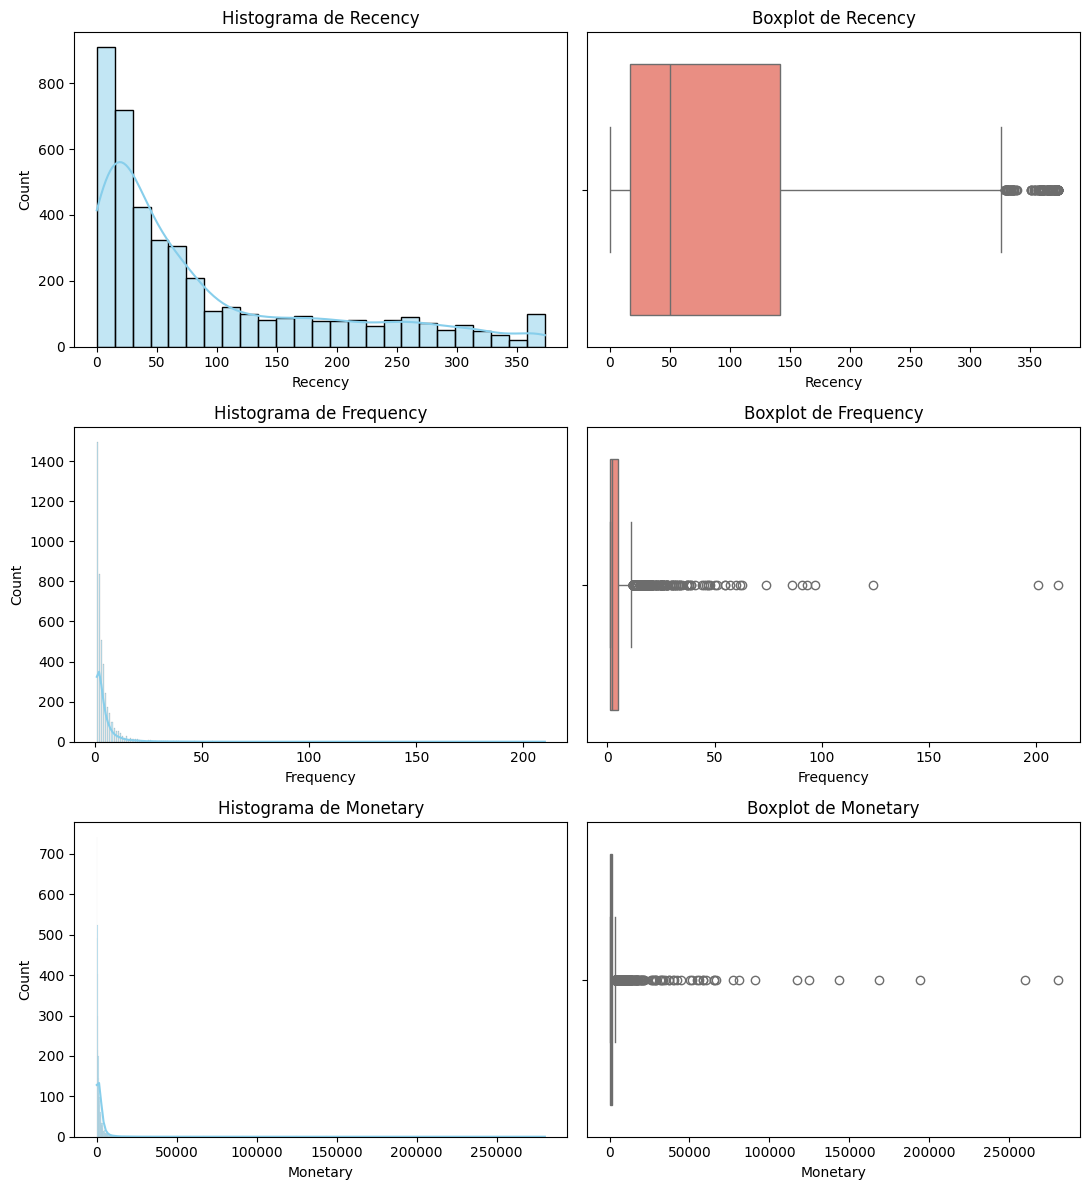

In [42]:
import os

fig, axes = plt.subplots(3, 2, figsize=(11,12))

colunas = ["Recency", "Frequency", "Monetary"]

for i, col in enumerate(colunas):
  sns.histplot(df_rfm[col], kde=True, ax=axes[i, 0], color='skyblue')
  axes[i, 0].set_title(f"Histograma de {col}")

  sns.boxplot(x=df_rfm[col], ax=axes[i, 1], color='salmon')
  axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')
plt.savefig('images/grafico_distribuicoes.png', dpi=300, bbox_inches='tight')
plt.show()

Os gráficos ilustram esse cenário, mostrando a assimetria das
distribuições e o elevado número de valores atípicos, especialmente em 'Frequency' e 'Monetary', onde os outliers elevam as médias e distorcem as distribuições.

Nesse contexto, se faz necessário o tratamento dos dados antes da aplicação do modelo de clusterização, tendo em vista que se trata de um algoritmo baseado no cálculo de distância entre pontos em um plano cartesiano, e por isso altamente sensível a valores extremos e dados fora de escala.

### Transformação Logarítmica e Normalização


A seguir, tratamento de transformação logarítmica desta base, o que tornará os valores mais proporcionais e a distribuição mais próxima da normal.  

Em sequência, normalização dos dados para trazer todas as variáveis para uma mesma escala:



In [43]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [44]:
# Transformação Logarítmica

df_rfm_log = df_rfm[['Recency', 'Frequency', 'Monetary']].copy()

for col in ['Recency', 'Frequency', 'Monetary']:
    df_rfm_log[col] = np.log1p(df_rfm_log[col])

df_rfm_log.head()

,Recency,Frequency,Monetary
0,5.786897,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.944439,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [45]:
# Normalização

scaler = StandardScaler()
df_rfm_scaled = scaler.fit_transform(df_rfm_log)
df_rfm_scaled

array([[ 1.43566077, -0.95501313,  3.69768662],
       [-1.9532954 ,  1.07452296,  1.41181999],
       [ 0.38306349,  0.38643726,  0.71904602],
       ...,
       [-1.24429685, -0.36141188, -1.10875557],
       [-1.74534262,  2.1780455 ,  0.8215225 ],
       [-0.02862716,  0.05975492,  0.73649444]])

In [46]:
# Transformando o resultado de volta em um DataFrame para facilitar a visualização

df_rfm_scaled = pd.DataFrame(df_rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
df_rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.435661,-0.955013,3.697687
1,-1.953295,1.074523,1.411820
2,0.383063,0.386437,0.719046
3,-0.619028,-0.955013,0.701362
4,1.401611,-0.955013,-0.611449


Visualização das distribuições das features normalizadas do novo DataFrame:

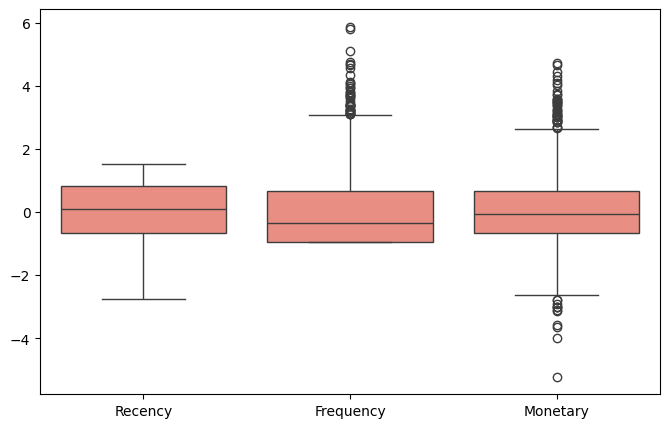

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(df_rfm_scaled, color='salmon')
plt.savefig('images/grafico_normalizadas.png', dpi=300, bbox_inches='tight')
plt.show()

Após as transformações nos dados, vemos por meio dos boxplots como as distribuições ficam mais simétricas e próximas da normal, e as distorções mais suavizadas. Neste ponto os dados estão prontos para ser aplicados ao modelo.

### Modelagem

#### Segmentação de clientes

Previamente à aplicação ao K-Means, implementação do 'Método do Cotovelo' para fornecer a base do número de clusters ideal:

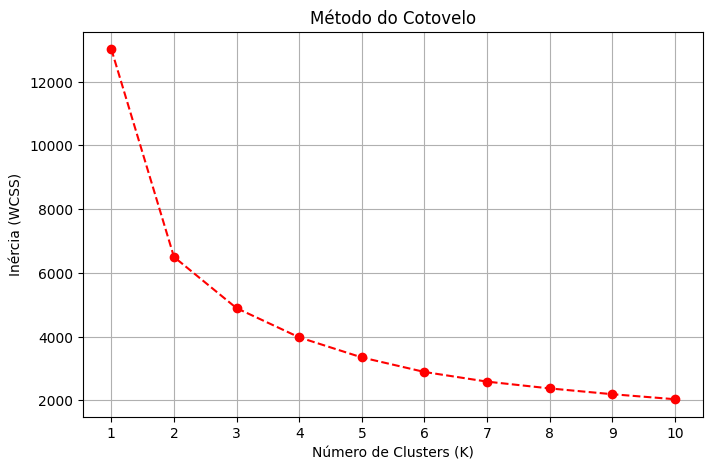

In [48]:
from sklearn.cluster import KMeans

# Lista para armazenar a inércia de cada K
inercias = []

# Testando valores de K de 1 a 10
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_rfm_scaled)
    inercias.append(kmeans.inertia_)

# Gráfico:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inercias, marker='o', linestyle='--', color='red')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo')
plt.xticks(K_range)
plt.grid(True)
plt.savefig('images/grafico_cotovelo.png', dpi=300, bbox_inches='tight')
plt.show()

O modelo foi rodado por 10 vezes para cada número de cluster, de 1 a 10, e exibe no gráfico as menores inércias encontradas para cada cluster.  
Quanto menor a queda de um ponto para o outro, menos clara fica a distinção de perfis entre os agrupamentos.  
A queda é significativa entre 1 e 2 clusters, e consideravelmente menor entre 2 e 3.  
Entre 3 e 4 cai para aproximadamente metade da anterior, o que sugere que a partir de 4 clusters o ganho de informação pode não ser tão relevante e trazer ruído para a análise.  
Por isso, visando o perfilamento mais equilibrado possível, o modelo será rodado com 3 clusters:


In [49]:
# Treinamento do modelo final com 3 clusters

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans_final.fit_predict(df_rfm_scaled)
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,325,1,77183.60,2
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,2
3,12349,18,1,1757.55,2
4,12350,310,1,334.40,1


A seguir vamos visualizar os gráficos de dispersão e densidade das features com os agrupamentos gerados pelo K-Means.  
Para facilitar a visualização das proporções reais de cada grupo, adiciono a coluna de clusters à tabela com os dados normalizados:

In [50]:
df_rfm_scaled['Cluster'] = df_rfm['Cluster']
df_rfm_scaled.head()

,Recency,Frequency,Monetary,Cluster
0,1.435661,-0.955013,3.697687,2
1,-1.953295,1.074523,1.411820,0
2,0.383063,0.386437,0.719046,2
3,-0.619028,-0.955013,0.701362,2
4,1.401611,-0.955013,-0.611449,1


##### Visualizações

<Figure size 800x600 with 0 Axes>

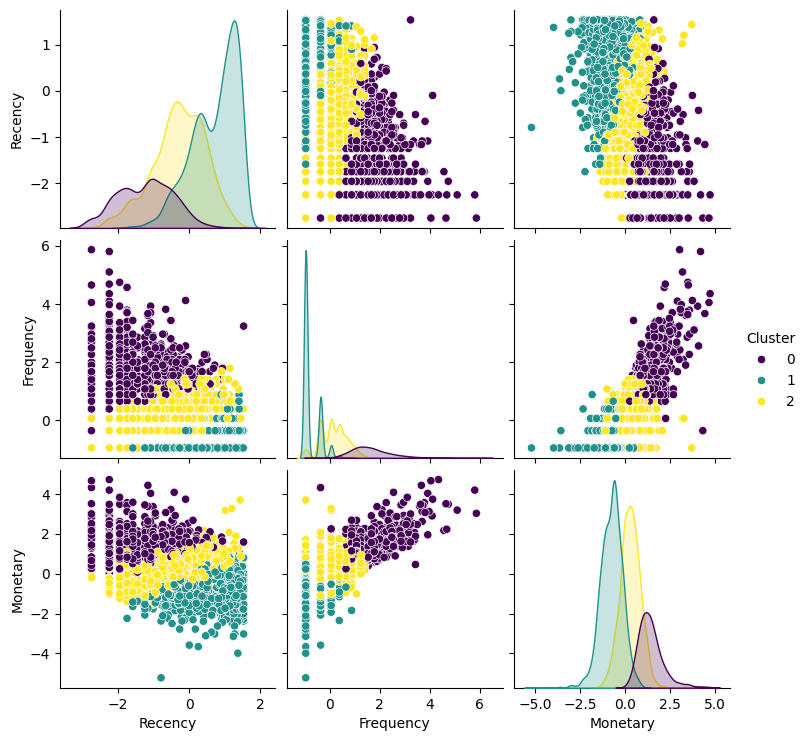

In [51]:
plt.figure(figsize=(8, 6))
sns.pairplot(df_rfm_scaled, hue='Cluster', palette='viridis')
plt.savefig('images/grafico_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

Nota-se o comportamento de cada grupo pela distinção de cada cor.  

O cluster 0, representado pela cor roxa demonstra ser um grupo de clientes mais ativos, com maiores gastos e frequência de pedidos maior.

O cluster 1, de cor verde, aparenta ser o oposto do cluster 0, com pontos de dados normalmente mais afastados deste último, como fica claro nos gráficos inferiores que mostram as dispersões de recência e frequência versus valor monetário.  

O cluster 2, de cor amarela, claramente são os pontos de dados que separam os outros dois clusters. São os clientes de nível intermediário, mas que em alguns aspectos se assemelham mais aos clientes do cluster 1, como mostram especialmente os gráficos Monetary x Frequency e Frequency x Recency.  

Pelos gráficos de densidade vemos que os clientes do cluster 0 estão em menor quantidade que os outros dois.



**Centróides**

Gráfico de exibição de centróides, o pontos centrais de cada cluster, dos quais as distâncias a cada ponto do agrupamento são calculadas:

In [52]:
centroides = kmeans_final.cluster_centers_
centroides

array([[-1.21813745,  1.65480552,  1.40073238],
       [ 0.71462937, -0.76753231, -0.78032295],
       [-0.28192651,  0.15174669,  0.27705879]])

In [53]:
centers = pd.DataFrame(centroides, columns=['Recency','Frequency','Monetary'])
centers

,Recency,Frequency,Monetary
0,-1.218137,1.654806,1.400732
1,0.714629,-0.767532,-0.780323
2,-0.281927,0.151747,0.277059


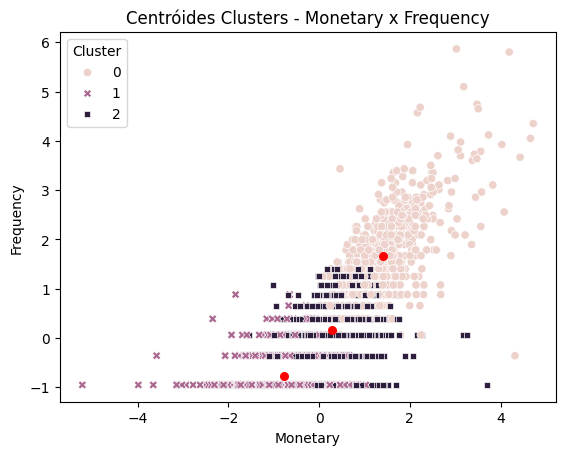

In [54]:
fig, ax = plt.subplots()
ax = sns.scatterplot(df_rfm_scaled, x='Monetary',y='Frequency', hue='Cluster', style='Cluster',ax=ax)
centers.plot.scatter(x='Monetary',y='Frequency', color='red', s=30, ax=ax)
plt.xlabel("Monetary")
plt.ylabel("Frequency")
plt.title("Centróides Clusters - Monetary x Frequency")
plt.savefig('images/grafico_centroides.png', dpi=300, bbox_inches='tight')
plt.show()

Os centróides representam os perfis médios de cada agrupamento, destacado pelos pontos vermelhos no gráfico.  
Nota-se que esses pontos não são equidistantes e não se distribuem de forma uniforme na dispersão.   
Isso reflete a alta assimetria dos dados e aponta para uma sobreposição natural nas fronteiras dos clusters, indicando clientes em zonas de transição que compartilham características de mais de um grupo.


##### Análise de perfis

In [55]:
# Média das métricas por cluster:

perfil_clusters = df_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2).reset_index()
perfil_clusters

,Cluster,Recency,Frequency,Monetary
0,0,13.52,13.61,7978.12
1,1,162.11,1.34,354.18
2,2,46.43,3.54,1391.49


In [56]:
# Contagem de clientes em cada grupo para conferir o tamanho de cada um:

perfil_clusters['Qtd_Clientes'] = df_rfm.groupby('Cluster')['CustomerID'].count().values
perfil_clusters

,Cluster,Recency,Frequency,Monetary,Qtd_Clientes
0,0,13.52,13.61,7978.12,735
1,1,162.11,1.34,354.18,1920
2,2,46.43,3.54,1391.49,1684


In [57]:
# Valor gasto em média por pedido em cada cluster:

perfil_clusters['Valor_por_Pedido'] = perfil_clusters['Monetary'] / perfil_clusters['Frequency']
perfil_clusters

,Cluster,Recency,Frequency,Monetary,Qtd_Clientes,Valor_por_Pedido
0,0,13.52,13.61,7978.12,735,586.195445
1,1,162.11,1.34,354.18,1920,264.313433
2,2,46.43,3.54,1391.49,1684,393.076271


Com o agrupamento realizado, é possível notar algumas particularidades nas features de cada cluster, tais como (valores em média):  

Grupo 0 (735 clientes):
- Última compra recente, há menos de 2 semanas;  
- Alto número de pedidos, acima de 13;   
- Alto valor total gasto, cerca de £ 8.000.

Grupo 1 (1920 clientes):
- Última compra há muito tempo, acima de 160 dias;  
- Baixo número de pedidos, menos de 2;  
- Baixo valor total gasto, cerca de £ 350.  

Grupo 2 (1684 clientes):
- Última compra não muito recente, cerca de 46 dias;  
- Baixo número de pedidos, menos de 4;  
- Valor total gasto intermediário, cerca de £ 1.390.   
  


O grupo 0 (Top Clients) se notabiliza por ser o menor cluster, mas o que mais contribui para o faturamento do e-commerce. São clientes já fidelizados que merecem algum reconhecimento.  

O grupo 1 se destaca pela inatividade, sendo o oposto do grupo 0. É o grupo que precisa de mais atenção para que voltem a ser ativos e aumentem o número de compras.  

O grupo 2 tem um perfil intermediário, com valor de gasto razoável, tendo em vista sua frequência, e que pode melhorar, tanto neste último aspecto, quanto no incremento do valor total gasto por pedido. Com os devidos incentivos, esse é o grupo mais favorável para ter crescimento.

#### Previsão de vendas

A seguir, preparação dos dados para os modelos supervisionados que serão treinados.  
A variável 'InvoiceDate' é a que representa as datas de compras do período abarcado pelo dataset, e assim será usada para separação dos dados em duas tabelas, uma com dados do histórico de compras, o "passado", e outra com dados do "futuro", que serão usados para treinamento e previsão.


##### Preparação

In [58]:
df['InvoiceDate'].describe()

,InvoiceDate
count,392732
mean,2011-07-10 19:15:24.576301568
min,2010-12-01 08:26:00
25%,2011-04-07 11:12:00
50%,2011-07-31 12:02:00
75%,2011-10-20 12:53:00
max,2011-12-09 12:50:00


In [59]:
print("Data Inicial:", df['InvoiceDate'].min())
print("Data Final:", df['InvoiceDate'].max())

Data Inicial: 2010-12-01 08:26:00
Data Final: 2011-12-09 12:50:00


Marco da divisão entre os dados passados e futuros: os 12 meses de dados serão divididos no nono mês, separando os 3 meses finais para atuarem como os registros futuros:

In [60]:
df_passado = df.loc[df['InvoiceDate'] < '2011-09-09']
df_futuro = df.loc[df['InvoiceDate'] >= '2011-09-09']

In [61]:
registros_passado = len(df_passado)
registros_futuro = len(df_futuro)
print(f"Registros passados: {registros_passado}")
print(f"Registros futuros: {registros_futuro}")

Registros passados: 232597
Registros futuros: 160135


In [62]:
percentual_passado = len(df_passado) / len(df)
percentual_futuro = len(df_futuro) / len(df)
print(f"Percentual de dados passados: {percentual_passado:.2%}")
print(f"Percentual de dados futuros: {percentual_futuro:.2%}")

Percentual de dados passados: 59.23%
Percentual de dados futuros: 40.77%


Construção de uma nova tabela RFM somente com dados do passado:

In [63]:
recency_passado = df_passado.groupby('CustomerID')['InvoiceDate'].max()
recency_passado = (df_passado['InvoiceDate'].max() - recency_passado).dt.days.reset_index(name='Recency')
recency_passado

,CustomerID,Recency
0,12346,233
1,12347,37
2,12348,156
3,12350,218
4,12352,170
...,...,...
3357,18280,185
3358,18281,88
3359,18282,34
3360,18283,3


In [64]:
frequency_passado = df_passado.groupby('CustomerID')['InvoiceNo'].nunique().reset_index(name='Frequency')
frequency_passado

,CustomerID,Frequency
0,12346,1
1,12347,5
2,12348,3
3,12350,1
4,12352,5
...,...,...
3357,18280,1
3358,18281,1
3359,18282,1
3360,18283,10


In [65]:
monetary_passado = df_passado.groupby('CustomerID')['Total'].sum().reset_index(name='Monetary')
monetary_passado

,CustomerID,Monetary
0,12346,77183.60
1,12347,2790.86
2,12348,1487.24
3,12350,334.40
4,12352,1561.81
...,...,...
3357,18280,180.60
3358,18281,80.82
3359,18282,100.21
3360,18283,1086.83


In [66]:
# Junção de Recência e Frequência
df_features = pd.merge(recency_passado, frequency_passado, on='CustomerID')

# Adicionando o Valor Monetário
df_features = pd.merge(df_features, monetary_passado, on='CustomerID')

df_features.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,233,1,77183.60
1,12347,37,5,2790.86
2,12348,156,3,1487.24
3,12350,218,1,334.40
4,12352,170,5,1561.81


Feature LTV futuro com dados do total gasto por cliente:

In [67]:
df_target = df_futuro.groupby('CustomerID')['Total'].sum().reset_index(name='ltv_futuro')
df_target

,CustomerID,ltv_futuro
0,12347,1519.14
1,12348,310.00
2,12349,1757.55
3,12352,944.23
4,12356,58.35
...,...,...
2893,18277,110.38
2894,18278,173.90
2895,18282,77.84
2896,18283,958.70


Formação do DataFrame final com a fusão de todos os dados preparados:

In [68]:
df_ltv = pd.merge(df_features, df_target, on='CustomerID', how='left')
df_ltv

,CustomerID,Recency,Frequency,Monetary,ltv_futuro
0,12346,233,1,77183.60,NaN
1,12347,37,5,2790.86,1519.14
2,12348,156,3,1487.24,310.00
3,12350,218,1,334.40,NaN
4,12352,170,5,1561.81,944.23
...,...,...,...,...,...
3357,18280,185,1,180.60,NaN
3358,18281,88,1,80.82,NaN
3359,18282,34,1,100.21,77.84
3360,18283,3,10,1086.83,958.70


In [69]:
df_ltv['ltv_futuro'] = df_ltv['ltv_futuro'].fillna(0)

In [70]:
df_ltv

,CustomerID,Recency,Frequency,Monetary,ltv_futuro
0,12346,233,1,77183.60,0.00
1,12347,37,5,2790.86,1519.14
2,12348,156,3,1487.24,310.00
3,12350,218,1,334.40,0.00
4,12352,170,5,1561.81,944.23
...,...,...,...,...,...
3357,18280,185,1,180.60,0.00
3358,18281,88,1,80.82,0.00
3359,18282,34,1,100.21,77.84
3360,18283,3,10,1086.83,958.70


In [71]:
df_ltv['ltv_futuro'].describe()

,ltv_futuro
count,3362.000000
mean,851.554944
std,5014.920605
min,0.000000
25%,0.000000
50%,175.355000
75%,700.280000
max,168469.600000


In [72]:
df_ltv['ltv_futuro'].quantile([0.25, 0.30, 0.40, 0.45])

,ltv_futuro
0.25,0.000
0.30,0.000
0.40,0.000
0.45,99.297


Chama atenção a quantidade de valores zero na distribuição da nova variável 'ltv_futuro'. Isso significa que muitos cientes da base, quase a metade, não fizeram compras nos três meses finais do período total de um ano.  

Há ainda o fato de haver os clientes "top", que impulsionam o faturamento desse período e causam a distorção observada.  

A conferir o quanto isso pode comprometer o desempenho do modelo.  

Prossigo abaixo com a etapa de treinamento e testes utilizando dois modelos tradicionais, Regressão Linear e Floresta Aleatória.  
  
Para mitigar prováveis efeitos adversos das distorções da base, realizo também a transformação logarítmica do dataframe usado nesta etapa.

In [73]:
from sklearn.model_selection import train_test_split

In [74]:
X = df_ltv.drop(columns=['CustomerID','ltv_futuro'])
y = df_ltv['ltv_futuro']

In [75]:
# Transformação Logarítmica nas Features e Target

X_log = np.log1p(X)
y_log = np.log1p(y)

In [76]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

In [77]:
X_train_log.head()

,Recency,Frequency,Monetary
1334,5.141664,0.693147,4.749790
676,3.433987,0.693147,5.791183
1399,3.737670,1.791759,6.631541
839,1.098612,2.302585,7.661598
999,3.091042,1.609438,7.001273


In [78]:
y_train_log.head()

,ltv_futuro
1334,0.000000
676,6.735032
1399,6.324000
839,5.827886
999,5.473572


In [79]:
print("Dimensão X_train:", X_train_log.shape)
print("Dimensão X_test:", X_test_log.shape)
print("Dimensão y_train:", y_train_log.shape)
print("Dimensão y_test:", y_test_log.shape)

Dimensão X_train: (2689, 3)
Dimensão X_test: (673, 3)
Dimensão y_train: (2689,)
Dimensão y_test: (673,)


##### Treinamento e Teste

In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [81]:
regressao = LinearRegression()
regressao.fit(X_train_log, y_train_log)

floresta = RandomForestRegressor(n_estimators=100, random_state=42)
floresta.fit(X_train_log, y_train_log)

RandomForestRegressor(random_state=42)

In [82]:
y_pred_regressao = regressao.predict(X_test_log)
y_pred_floresta = floresta.predict(X_test_log)

In [83]:
y_test_original = np.expm1(y_test_log)
y_pred_reg_original = np.expm1(y_pred_regressao)
y_pred_flo_original = np.expm1(y_pred_floresta)

In [84]:
y_pred_reg_original = np.clip(y_pred_reg_original, 0, None)
y_pred_flo_original = np.clip(y_pred_flo_original, 0, None)

Nota: Acima foi aplicada reversão logarítmica para os valores originais, a fim de ser possível avaliar as métricas dos resultados, principalmente o MAE, que é dado em valor monetário, nesse caso, em libras.  


In [85]:
# Métricas Regressão Linear:

r2_regressao = r2_score(y_test_original, y_pred_reg_original)
mae_regressao = mean_absolute_error(y_test_original, y_pred_reg_original)

In [86]:
y_pred_flo_original = np.clip(y_pred_flo_original, 0, y_test_original.max() * 2)

r2_floresta = r2_score(y_test_original, y_pred_flo_original)
mae_floresta = mean_absolute_error(y_test_original, y_pred_flo_original)

Nota 2: Outro ajuste realizado foi a utilização do método "clip" para evitar valores abaixo de zero e infinito que a transformação logarítmica causa.

##### Resultados

In [87]:
print("=== REGRESSÃO LINEAR ===")
print(f"MAE: £{mae_regressao:.2f}")
print(f"R²: {r2_regressao:.4f}\n")

print("=== RANDOM FOREST REGRESSOR ===")
print(f"MAE: £{mae_floresta:.2f}")
print(f"R²: {r2_floresta:.4f}")

=== REGRESSÃO LINEAR ===
MAE: £900.82
R²: -0.0682

=== RANDOM FOREST REGRESSOR ===
MAE: £772.44
R²: 0.0475


Mesmo com o tratamento prévio à exposição aos modelos, os resultados não atingiram o objetivo de produzir métricas robustas.
O MAE retornou valores muito altos e o R² ficou negativo nos dois modelos, evidenciando a inefetividade do aprendizado de ambos. Com essa métrica abaixo de zero, conclui-se que o modelo não é capaz de estimar valores que sejam mais ajustados do que a própria média, ficando no terreno da aleatoriedade.

Diante desse cenário, procurei um modelo que pudesse contornar esse desafio e produzir métricas mais positivas.  
A seguir utilizo o algoritmo de ensemble XGBoost, com a configuração do hiperparâmetro chamado de função "Tweedie", que pode lidar bem com dados de alta variância, como os deste dataset, que apresentam muitos valores zero e que ao longo da distribuição se elevam significativamente.

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
!pip install xgboost

In [90]:
import xgboost as xgb

modelo_xgb = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    n_estimators=100,
    random_state=42,
    learning_rate=0.1
)

# Treinamento
modelo_xgb.fit(X_train, y_train)

# Previsão
y_pred_xgb = modelo_xgb.predict(X_test)

# Resultados
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("=== XGBOOST REGRESSOR (TWEEDIE LOSS) ===")
print(f"MAE: £{mae_xgb:.2f}")
print(f"R²: {r2_xgb:.4f}\n")



=== XGBOOST REGRESSOR (TWEEDIE LOSS) ===
MAE: £746.03
R²: 0.0554



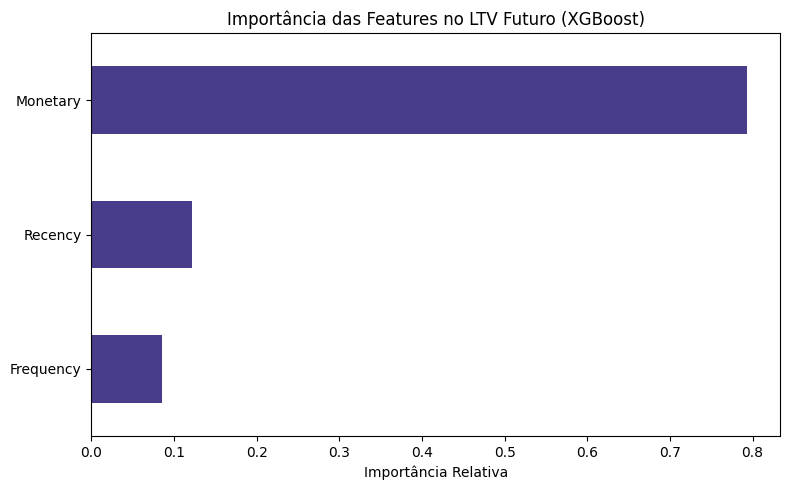

In [91]:
# Extraindo e plotando o Feature Importance
importancias = pd.Series(modelo_xgb.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='darkslateblue')
plt.title('Importância das Features no LTV Futuro (XGBoost)')
plt.xlabel('Importância Relativa')
plt.tight_layout()
plt.savefig('images/grafico_importancias.png', dpi=300, bbox_inches='tight')
plt.show()

Com o XGBoost, os resultados permanecem abaixo do desejado inicialmente, mas foram melhores do que os da Regressão Linear e Floresta Aleatória.

Ao menos o R² não está mais negativo, ou seja, houve uma ligeira melhora, de modo que pode se dizer que o modelo agora é capaz de explicar 5,5% da variância do comportamento futuro de compras dos clientes.

Neste projeto procurei implementar uma solução de negócios em duas etapas: a de segmentação de clientes, em que foram identificados 3 perfis claros de clientes (Tops, Intermediários e Inativos), e a de previsão de faturamento.  
Esta última etapa demonstrou a dificuldade de se lidar com bases como a utilizada, com apenas três variáveis, em que há muitos clientes sem compras no trecho final do período disponível, além dos clientes que, na outra ponta, inflam os números do faturamento e acabam comprometendo a precisão dos modelos.  
O melhor resultado foi de 5,5% de redução de erro (R²), o que ao menos é suficiente para a superação da média.  
Como esperado, o modelo identificou que o histórico de valor monetário é o fator de maior peso para prever o faturamento futuro.  


